In [1]:
#test this

In [1]:
import alphapepttools as apt

/Users/jnimoca/Jose_BI/1_Repositories/HUPO_scverse_demo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_to_parquet = "/Volumes/RD_Coscia/Jose/P37_RevisionOpenDVP_JoseNimo/P37E01_DVP_Comparison/P37E01_DVP_comparisons_quicksearch/DIANN_output_refined_lib_final/report.parquet"

In [3]:
# Read precursor, protein and gene-level AnnDatas into a MuLink instance
adata_precursor = apt.io.read_psm_table(
    file_paths=path_to_parquet,
    search_engine="diann",
    level="precursors",
    var_columns=["proteins", "genes"],  # include protein and gene annotation for precursor-level data
)

adata_protein = apt.io.read_psm_table(
    file_paths=path_to_parquet,
    search_engine="diann",
    level="proteins",
    var_columns="genes",  # include gene annotation for protein-level data
)

adata_gene = apt.io.read_psm_table(
    file_paths=path_to_parquet,
    search_engine="diann",
    level="genes",
)

mlink = apt.io.mulink_from_anndatas(
    anndatas={
        "precursors": adata_precursor,
        "proteins": adata_protein,
        "genes": adata_gene,
    }
)

100%|██████████| 2/2 [00:00<00:00, 10.37it/s]


In [6]:
adata_gene.var

""
genes
""
A1BG
A2M
A2ML1
AAAS
...
ZSWIM8
ZW10
ZYX


In [8]:
adata_protein.var

,genes
proteins,
A0A024R1R8;Q9Y2S6,TMA7;TMA7B
A0A075B6H7,IGKV3-7
A0A075B6I0,IGLV8-61
A0A075B6J9,IGLV2-18
A0A075B6K5;P80748,IGLV3-21;IGLV3-9
...,...
Q9Y6W3,CAPN7
Q9Y6W5,WASF2
Q9Y6X3,MAU2


In [9]:
adata_protein.obs

""
raw_name
Bluto_20251020_JoN_P37E01_991_Cancer_scDVP_64_S2-A4_1_14757
Bluto_20251020_JoN_P37E02_991_Cancer_scDVP_38_S2-E10_1_14789
Bluto_20251020_JoN_P37E03_991_Cancer_scDVP_28_S2-F11_1_14767
Bluto_20251020_JoN_P37E04_991_Cancer_scDVP_44_S2-B11_1_14760
Bluto_20251020_JoN_P37E05_991_Cancer_DVP_3_S3-D8_1_14826
...
Bluto_20251027_JoN_P37E01_992_MAC_DVP_02_S4-E12_1_14976
Bluto_20251027_JoN_P37E01_992_MAC_DVP_03_S4-D8_1_14977
Bluto_20251027_JoN_P37E01_992_MAC_scDVP_03_S4-F8_1_15021


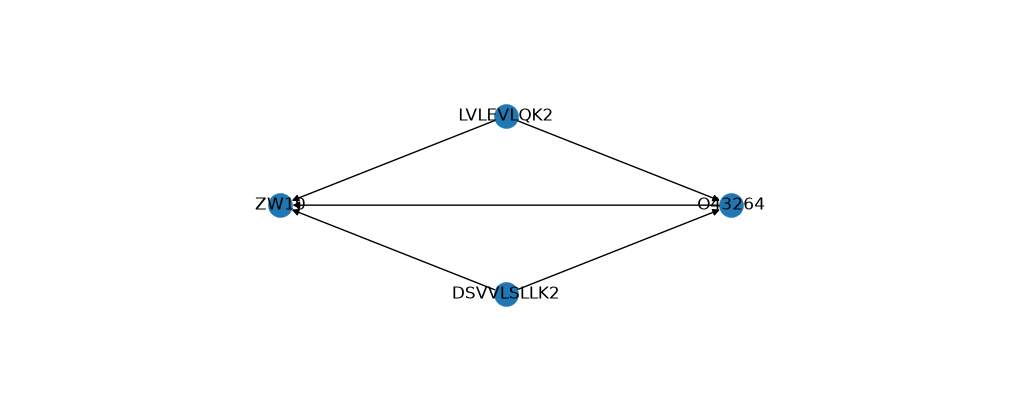

In [7]:
import matplotlib.pyplot as plt

fig, axm = apt.pl.create_figure(1, 1, figsize=(10, 4))
ax = axm.next()
(mlink.link.query.ancestors("ZW10").link.pl.graph(with_labels=True, ax=ax))
plt.margins(0.5)
plt.show()

In [ ]:
# Question: which proteins and precursors are associated with the "TF" and the "SERPINA3" gene?

# get filtered AnnDatas:
tf_genes = mlink.link.query.ancestors(["TF", "SERPINA3"]).mod["genes"]
tf_proteins = mlink.link.query.ancestors(["TF", "SERPINA3"]).mod["proteins"]
tf_precursors = mlink.link.query.ancestors(["TF", "SERPINA3"]).mod["precursors"]

# Assign a color based on the underlying gene to each precursor
gene_colors = {"TF": "blue", "SERPINA3": "orange"}
precursor_colors = tf_precursors.var["genes"].map(gene_colors).to_dict()

# Display precursors as a barplot
fig, axm = apt.pl.create_figure(1, 1, figsize=(14, 8))
ax = axm.next()

# log-transform y axis
ax.set_yscale("log")

# TF precursors
apt.pl.violinplot(
    ax=ax,
    data=tf_precursors.to_df(),
    direct_columns=tf_precursors.var_names,
    color_dict=precursor_colors,
)

# Add legend
apt.pl.add_legend_to_axes(
    ax=ax,
    levels=gene_colors,
)

# rotate x labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.show()